# Systematic Eval

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np

import pandas as pd
from TSB_AD.model_wrapper import run_Unsupervise_AD
from TSB_AD.evaluation.metrics import get_metrics
from pyod.models.ts_kshape import KShape
import matplotlib.pyplot as plt
from pyod.models.ts_od import TimeSeriesOD
from TSB_AD.evaluation.basic_metrics import basic_metricor

### Load data

In [10]:
data_direc = 'Datasets/TSB-AD-U/003_NAB_id_3_WebService_tr_1362_1st_1462.csv'

# Loading Data
df = pd.read_csv(data_direc).dropna()
data = df.iloc[:, 0:-1].values.astype(float)
label = df['Label'].astype(int).to_numpy()

#Get anomaly range:
grader = basic_metricor()
range_anomaly = grader.range_convers_new(label)

### Plot

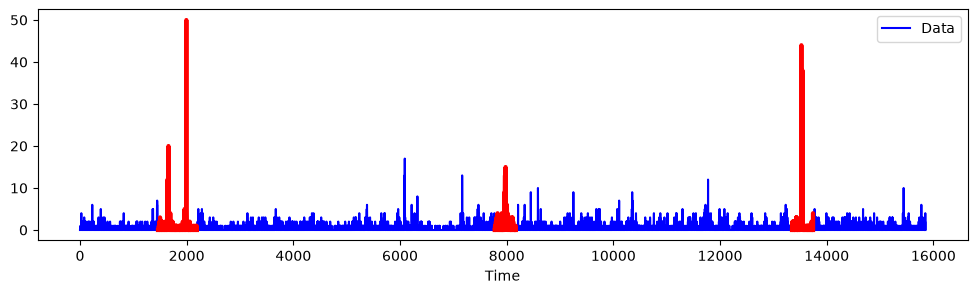

In [11]:
plt.figure(figsize=(12, 3))
plt.plot(range(len(data)), data, color='blue', label='Data')

for r in range_anomaly:
    if r[0] == r[1]:
        plt.scatter(r[0], data[r[0]], color='red', s=80, alpha=0.7)
    else:
        plt.plot(range(r[0], r[1]+1), data[r[0]:r[1]+1], color='red', linewidth=3)
plt.legend()
plt.xlabel('Time')
plt.show()


# Systematic model eval

In [15]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
)

train_end = 1362
test_start = 1462


models = [
    "IForest",
    "KNN",
    "ECOD",
    "COPOD",
    "HBOS",
    "LOF",
    "PCA",
    "INNE",
    "OCSVM",
    "MCD",
    "GMM",
    "LODA",
]

results = []

for model in models:
    clf = TimeSeriesOD(
        detector=model,
        window_size=10,
        step=1,
        score_aggregation="max",
        contamination=0.01,
    )
    clf.fit(data[:train_end])
    all_scores = clf.decision_function(data)

    # Apply the same calibration method to every model
    threshold = np.percentile(
        all_scores[train_end:test_start],
        99.0,
    )

    scores = all_scores[test_start:]
    predicted = scores > threshold

    test_label = label[test_start:]
    results.append({
        "Model": model,
        "Precision": precision_score(test_label, predicted, zero_division=0),
        "Recall": recall_score(test_label, predicted, zero_division=0),
        "F1": f1_score(test_label, predicted, zero_division=0),
        "ROC AUC": roc_auc_score(test_label, scores),
        "PR AUC": average_precision_score(test_label, scores),
        "Predictions": predicted.sum()
    })


results_df = pd.DataFrame(results)
results_df.sort_values("F1", ascending=False)


,Model,Precision,Recall,F1,ROC AUC,PR AUC,Predictions
8,OCSVM,0.798780,0.086014,0.155305,0.508911,0.187556,164
1,KNN,0.711957,0.086014,0.153486,0.501581,0.195624,184
6,PCA,0.711957,0.086014,0.153486,0.508600,0.196558,184
10,GMM,0.643902,0.086671,0.152778,0.507688,0.194703,205
9,MCD,0.800000,0.081418,0.147795,0.506148,0.195077,155
11,LODA,0.490909,0.035456,0.066136,0.510482,0.142190,110
4,HBOS,1.000000,0.027577,0.053674,0.488451,0.153230,42
2,ECOD,0.656250,0.027577,0.052930,0.498191,0.162852,64
3,COPOD,0.656250,0.027577,0.052930,0.496143,0.161776,64
0,IForest,0.672131,0.026921,0.051768,0.496411,0.156347,61


### Plot and show best results

OCSVM : 0.15530527563722585
KNN : 0.15348564733450498
PCA : 0.15348564733450498


,Model,Window Size,Precision,Recall,F1,ROC AUC,PR AUC,Predictions
0,LODA,30,0.560377,0.195010,0.289333,0.545110,0.293412,530
1,LODA,20,0.584699,0.140512,0.226575,0.524883,0.241757,366
2,LODA,10,0.711957,0.086014,0.153486,0.508600,0.196558,184


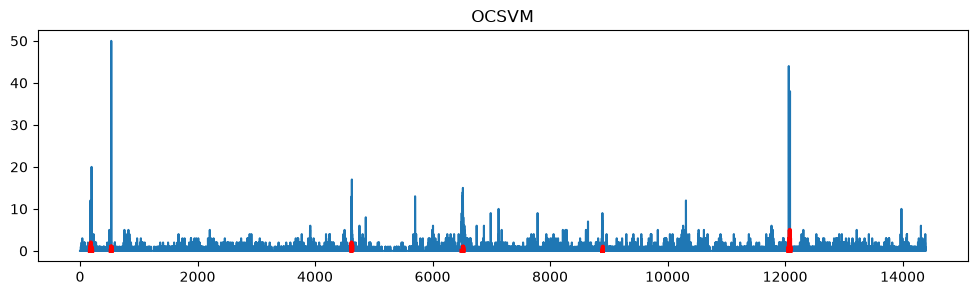

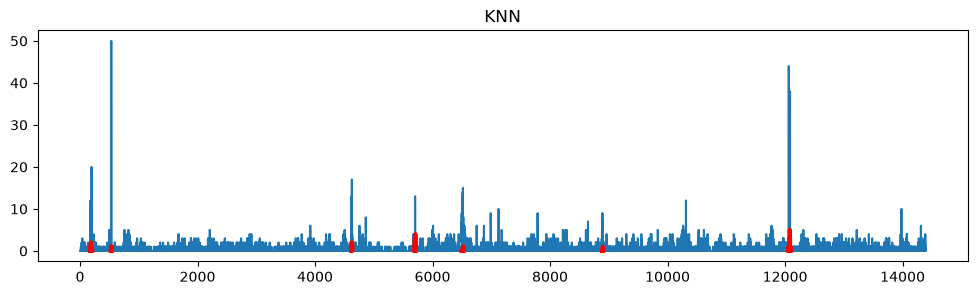

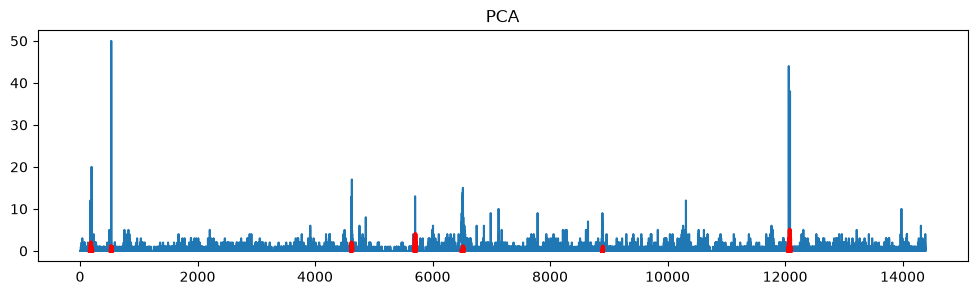

In [19]:
best_results = results_df.sort_values("F1", ascending=False).head(3)
for _, result in best_results.iterrows():
    print(result["Model"], ":", result["F1"])

    plt.figure(figsize=(12,3))
    plt.plot(range(len(data[test_start:])), data[test_start:])

    best_results = []
    for window_size in [30, 20, 10]:
        clf = TimeSeriesOD(
            detector=result["Model"],
            window_size=window_size,
            step=1,
            score_aggregation="max",
            contamination=0.01,
        )
        clf.fit(data[:train_end])
        all_scores = clf.decision_function(data)

        # Apply the same calibration method to every model
        threshold = np.percentile(
            all_scores[train_end:test_start],
            99.0,
        )

        scores = all_scores[test_start:]
        predicted = scores > threshold

        best_results.append(
            {
                "Model": model,
                "Window Size": window_size,
                "Precision": precision_score(test_label, predicted, zero_division=0),
                "Recall": recall_score(test_label, predicted, zero_division=0),
                "F1": f1_score(test_label, predicted, zero_division=0),
                "ROC AUC": roc_auc_score(test_label, scores),
                "PR AUC": average_precision_score(test_label, scores),
                "Predictions": predicted.sum()
            }
        )

        

    anom_ranges = grader.range_convers_new(predicted.astype(int))
    for r in anom_ranges:

        if r[0] == r[1]:
            plt.scatter(r[0], data[r[0]], color="red")
        else:
            plt.plot(range(r[0], r[1]+1), data[r[0]:r[1]+1], color='red', linewidth=3, label='True anomalies')
        plt.title(result["Model"])



In [20]:
best_results_df = pd.DataFrame(best_results)
best_results_df.sort_values("F1", ascending=False)

,Model,Window Size,Precision,Recall,F1,ROC AUC,PR AUC,Predictions
0,LODA,30,0.560377,0.195010,0.289333,0.545110,0.293412,530
1,LODA,20,0.584699,0.140512,0.226575,0.524883,0.241757,366
2,LODA,10,0.711957,0.086014,0.153486,0.508600,0.196558,184
